# Volterra signature validation

## Overview

| Section | What is validated |
|---|---|
| **1** | `vsig_fft` (orders 0-2) + predictor-corrector convergence |
| **2** | XLA FLOP-count scaling — FFT vs quadratic (`vsig`) |
| **3** | FSSK rough approximation vs predictor-corrector reference (R-sweep) |
| **4** | `FSSKConvolutionKernel` adapter correctness |

Paths are always **3-dimensional unit-speed** (total variation ≈ T, A = I_3).

In [2]:
OUTPUT_DIR = "validation_outputs"


## 1. `vsig_fft` vs predictor-corrector convergence

Compares vsig_fft (orders 0, 1, 2) and the fractional PC scheme against a
high-accuracy vsig_fft reference as either the grid step count or the dyadic
refinement order increases.

Set `convergence_mode = "steps"` to sweep step counts (loglog in h), or
`"dyadic"` to sweep dyadic refinement at fixed step count (semilogy in order).


In [10]:
REGIME = "3d"   # "draft" | "paper"

_REGIMES = {
    "2d": dict(
        convergence_mode = "dyadic",
        betas_vsig       = [0.1, 0.6],
        trunc_vsig       = 6,
        batch_vsig       = 6,
        T_vsig           = 1.0,
        seed_vsig        = 7,
        dim_vsig         = 2,
        vsig_orders      = [0, 1, 2],
        n_timing_repeats = 3,
        # "steps" mode
        steps_list       = [8, 16, 32, 64, 128],
        ref_steps_factor = 4,
        # "dyadic" mode
        fixed_steps      = 2 ** 6,
        vsig_dyadic_max  = 4,
        pc_dyadic_max    = 8,
        ref_dyadic_extra = 1,
    ),
    "3d": dict(
        convergence_mode = "dyadic",
        betas_vsig       = [0.1, 0.6],
        trunc_vsig       = 6,
        batch_vsig       = 16,
        T_vsig           = 1.0,
        seed_vsig        = 7,
        dim_vsig         = 3,
        vsig_orders      = [0, 1, 2],
        n_timing_repeats = 3,
        # "steps" mode
        steps_list       = [8, 16, 32, 64, 128],
        ref_steps_factor = 4,
        # "dyadic" mode
        fixed_steps      = 2 ** 5,
        vsig_dyadic_max  = 4,
        pc_dyadic_max    = 10,
        ref_dyadic_extra = 1,
    ),
}

_cfg = _REGIMES[REGIME]
convergence_mode  = _cfg["convergence_mode"]
betas_vsig        = _cfg["betas_vsig"]
trunc_vsig        = _cfg["trunc_vsig"]
batch_vsig        = _cfg["batch_vsig"]
T_vsig            = _cfg["T_vsig"]
seed_vsig         = _cfg["seed_vsig"]
dim_vsig          = _cfg["dim_vsig"]
vsig_orders       = _cfg["vsig_orders"]
n_timing_repeats  = _cfg["n_timing_repeats"]
steps_list        = _cfg["steps_list"]
ref_steps_factor  = _cfg["ref_steps_factor"]
fixed_steps       = _cfg["fixed_steps"]
vsig_dyadic_max   = _cfg["vsig_dyadic_max"]
pc_dyadic_max     = _cfg["pc_dyadic_max"]
ref_dyadic_extra  = _cfg["ref_dyadic_extra"]


In [11]:
import subprocess, sys
from pathlib import Path

script = Path("validation/analyse_vsig_convergence.py").resolve()
result = subprocess.run(
    [sys.executable, str(script),
     "--mode",       convergence_mode,
     "--output-dir", str(Path("validation") / OUTPUT_DIR),
    ],
    cwd=str(script.parent.parent),
)
if result.returncode != 0:
    raise RuntimeError(f"analyse_vsig_convergence.py failed (exit {result.returncode})")


Loaded: validation/validation_outputs/vsig_conv_dyadic.pkl  (364 terminal rows)
  convergence_mode = dyadic
  betas = [0.1, 0.6]

β = 0.1
  Saved: validation/validation_outputs/vsig_conv_dyadic_b0p10_convergence.pdf
  Saved: validation/validation_outputs/vsig_conv_dyadic_b0p10_convergence.png
  Saved: validation/validation_outputs/vsig_conv_dyadic_b0p10_tradeoff.pdf
  Saved: validation/validation_outputs/vsig_conv_dyadic_b0p10_tradeoff.png

β = 0.6
  Saved: validation/validation_outputs/vsig_conv_dyadic_b0p60_convergence.pdf
  Saved: validation/validation_outputs/vsig_conv_dyadic_b0p60_convergence.png
  Saved: validation/validation_outputs/vsig_conv_dyadic_b0p60_tradeoff.pdf
  Saved: validation/validation_outputs/vsig_conv_dyadic_b0p60_tradeoff.png

Saved: validation/validation_outputs/vsig_conv_dyadic_rates.csv

── Convergence rates ─────────────────────────────────────────────
 beta method  order  conv_rate
  0.1   vsig    0.0   0.080380
  0.1   vsig    1.0   0.835814
  0.1   vsig   

,beta,method,order,conv_rate
0,0.1,vsig,0.0,0.080380
1,0.1,vsig,1.0,0.835814
2,0.1,vsig,2.0,1.125159
3,0.1,pc,NaN,1.172553
4,0.6,vsig,0.0,0.551803
5,0.6,vsig,1.0,1.471319
6,0.6,vsig,2.0,1.182019
7,0.6,pc,NaN,1.539157


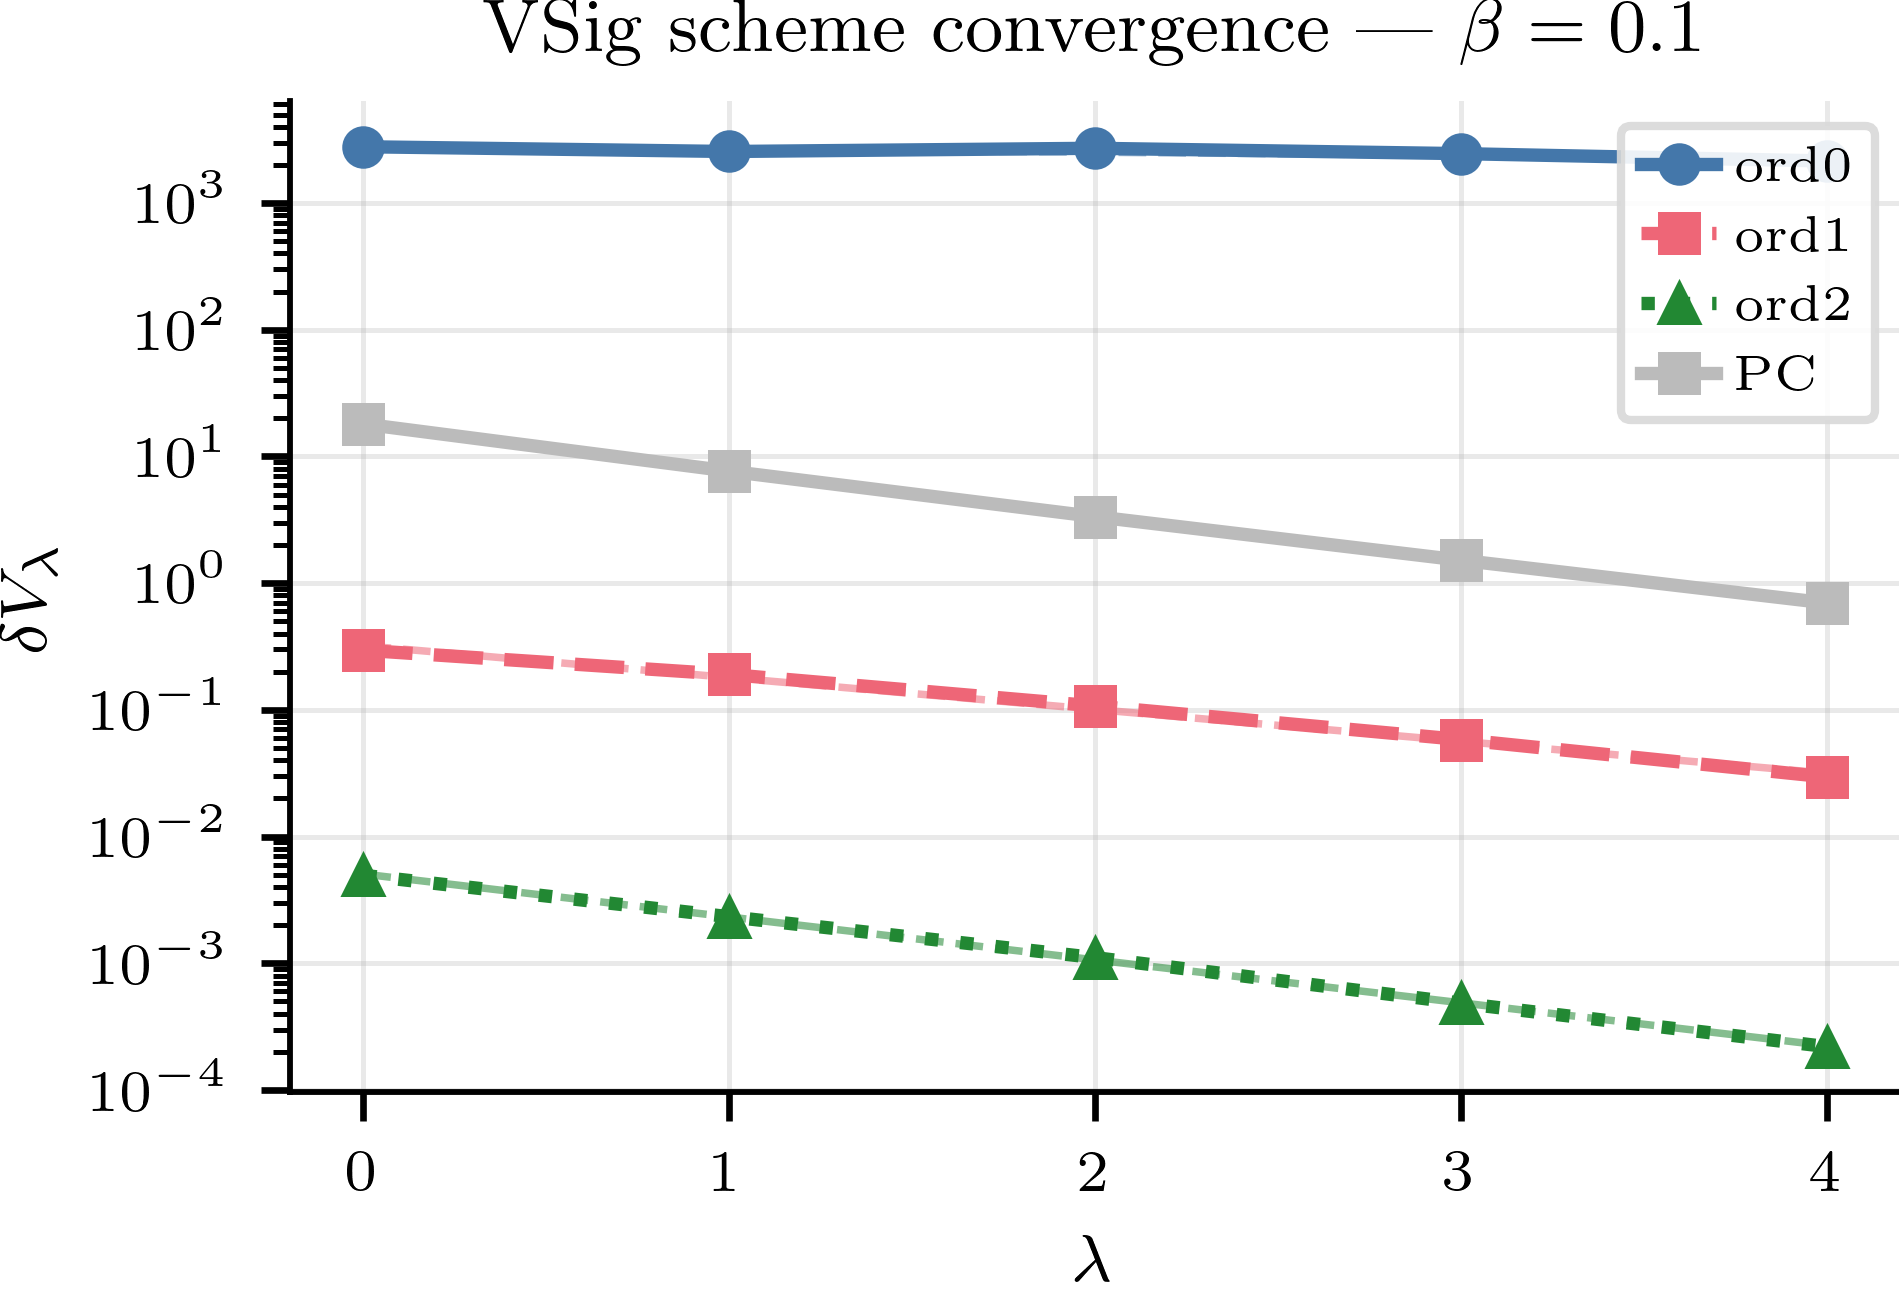

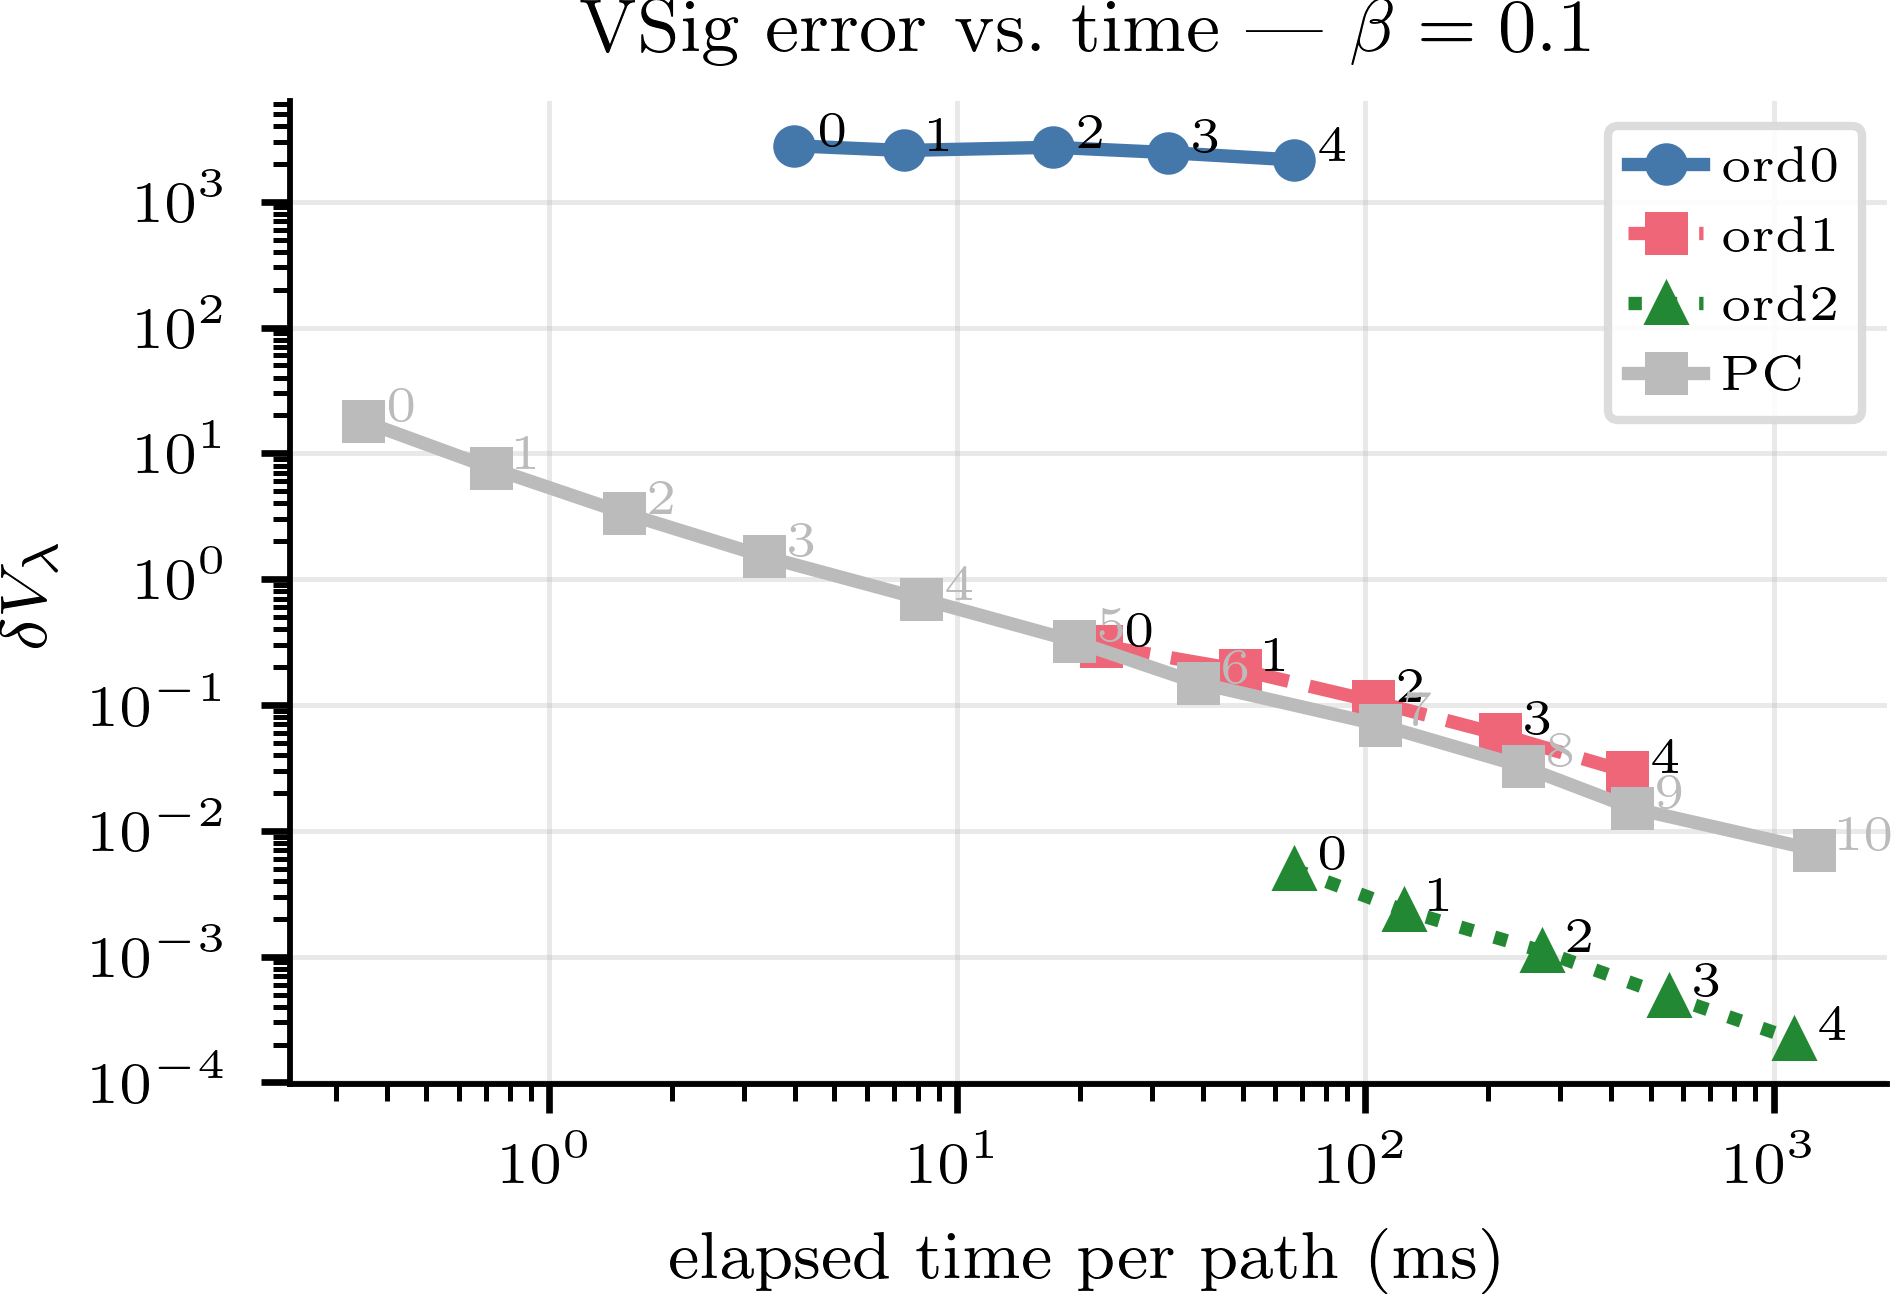

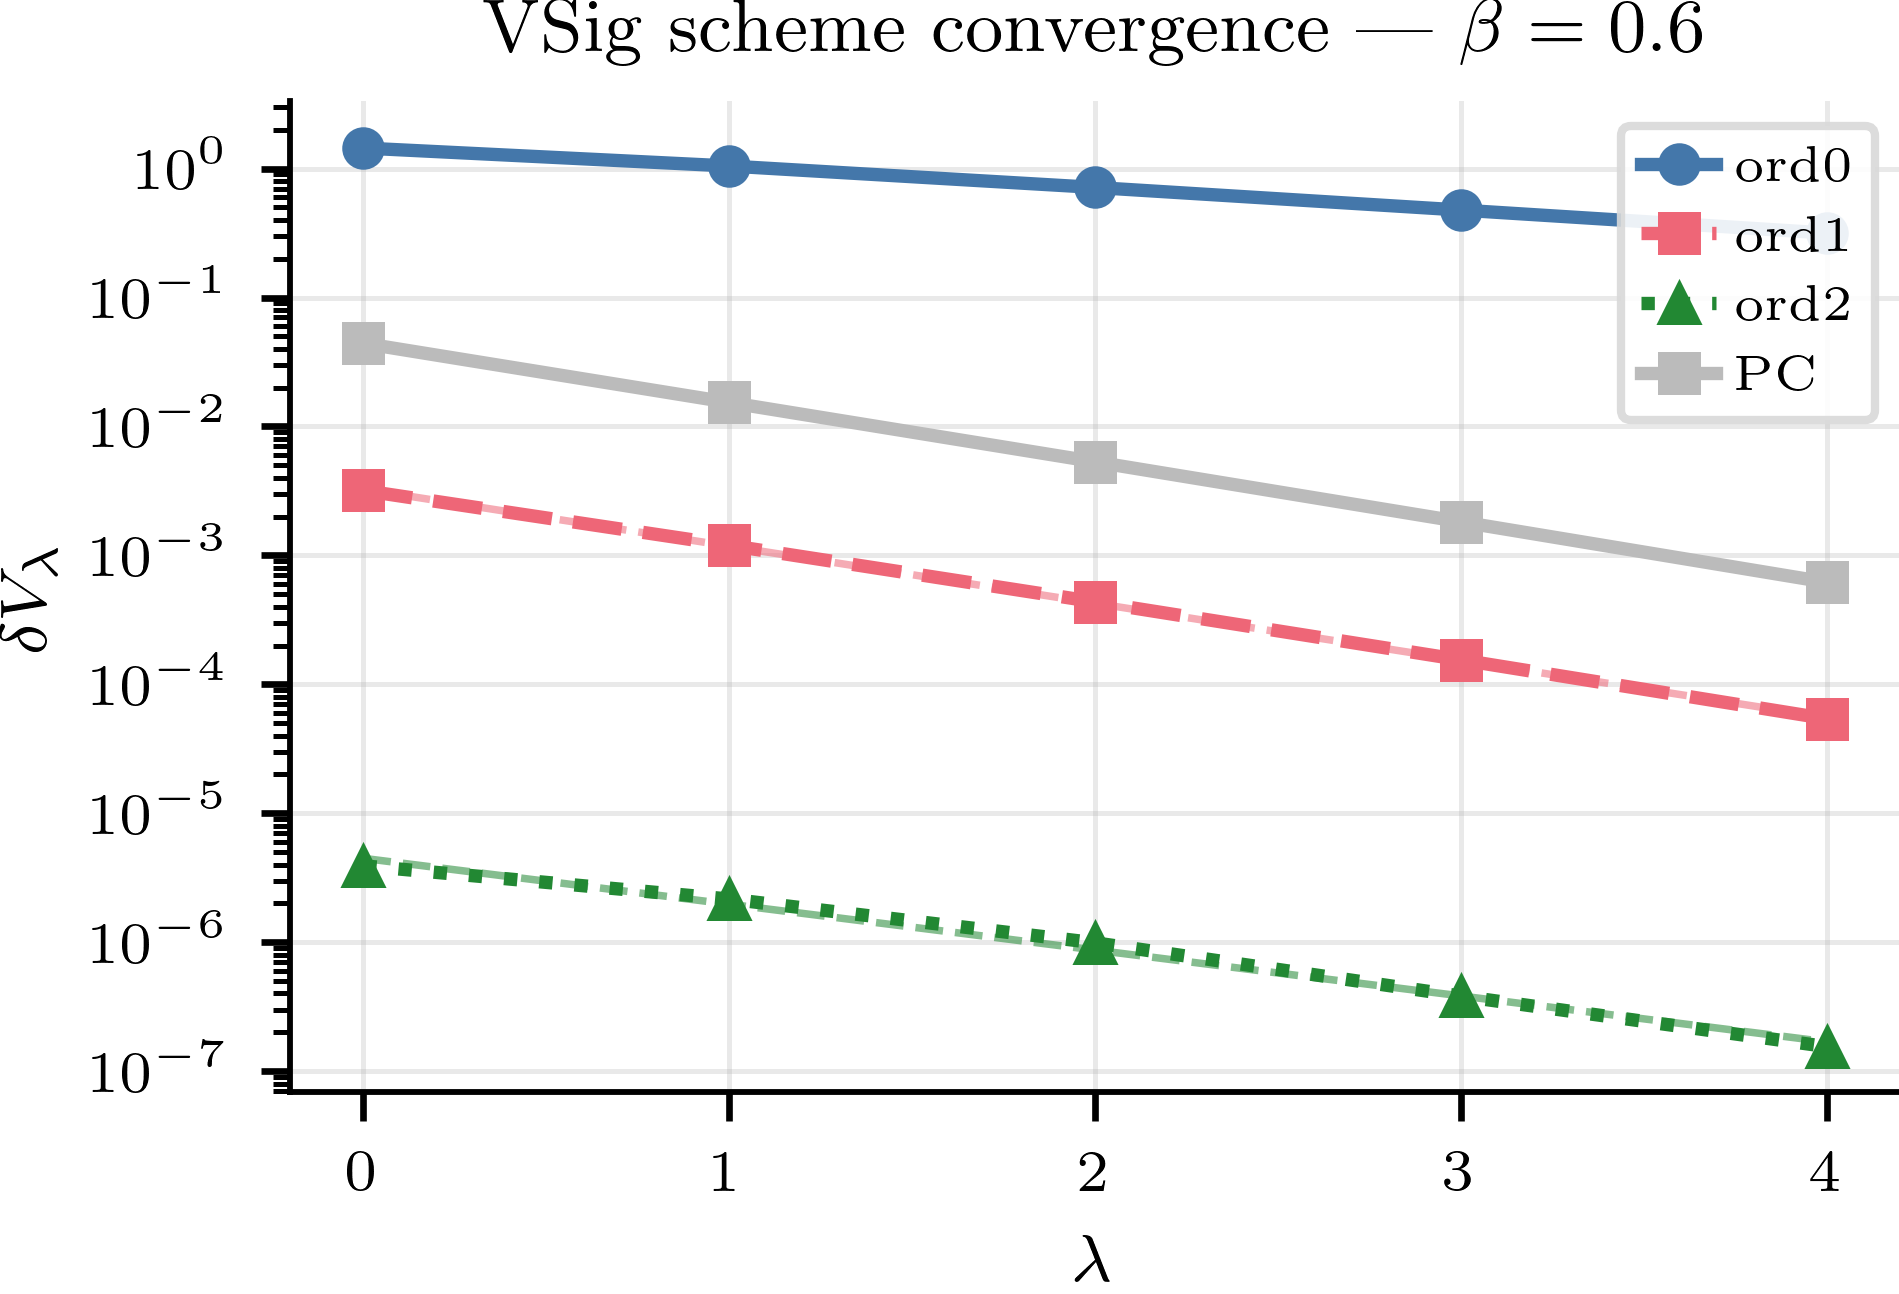

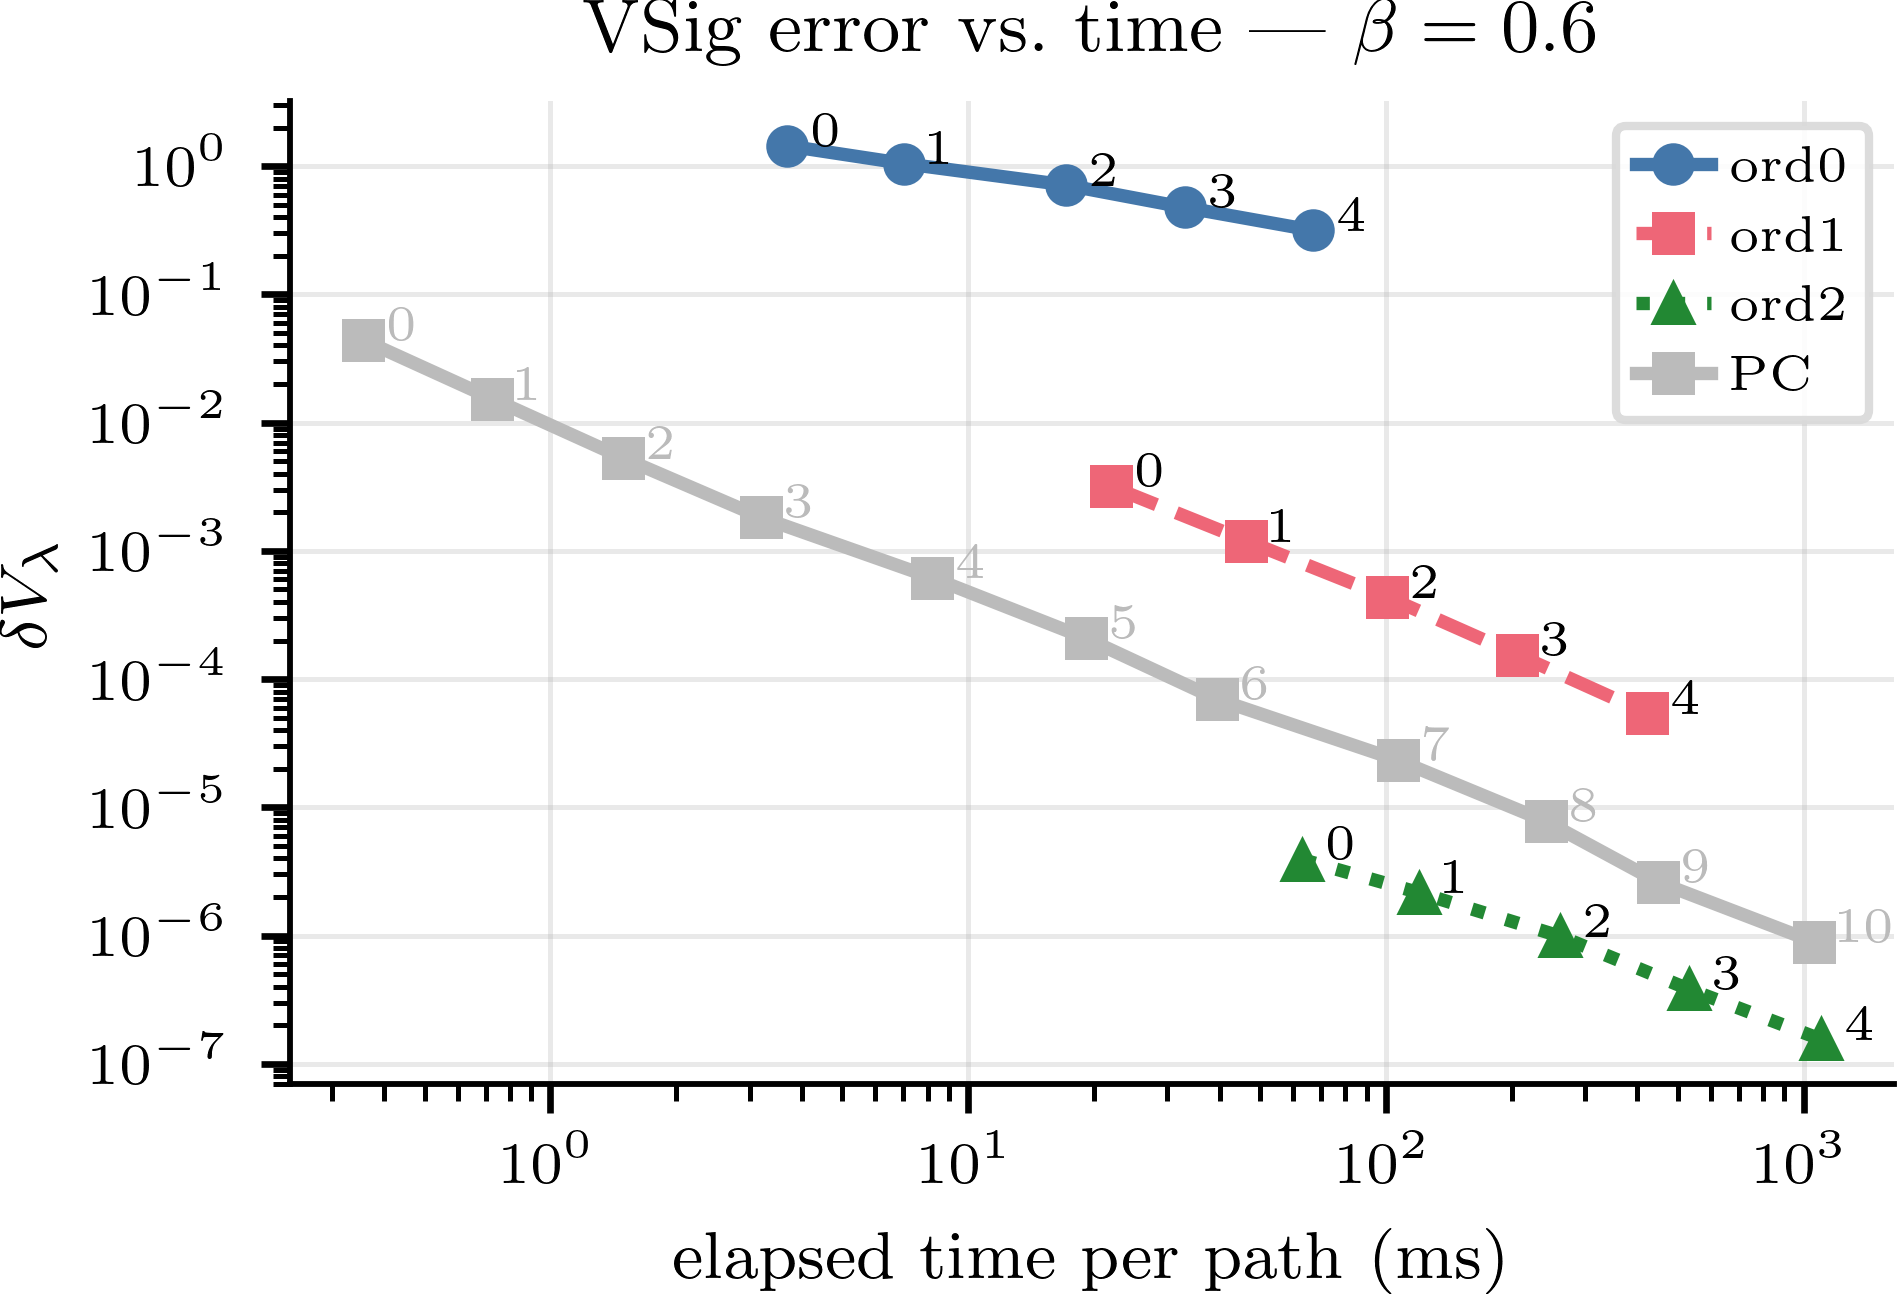

In [12]:
from pathlib import Path
from IPython.display import display, Image
import pandas as pd

out = Path("validation") / OUTPUT_DIR
mode = convergence_mode

display(pd.read_csv(out / f"vsig_conv_{mode}_rates.csv"))

for beta in betas_vsig:
    beta_tag = f"b{beta:.2f}".replace(".", "p")
    for suffix in ["_convergence", "_tradeoff"]:
        img = out / f"vsig_conv_{mode}_{beta_tag}{suffix}.png"
        if img.exists():
            display(Image(filename=str(img)))
        else:
            print(f"  (not found: {img.name})")


## 2. XLA FLOP-count scaling — FFT vs quadratic

Sweeps `(J, N, q)` with `order=2` and `dyadic_order=0` fixed.  For each
configuration three FLOP counts are profiled via abstract (device-free) XLA
compilation:

* **fft_pre** — lag-table precomputation (`precompute_lag_tables`)
* **fft_hot** — FFT hot loop with precomputed tables (`fft_iteration`)
* **quad**    — quadratic hot loop (`quadratic_iteration`)

`fft_total = fft_pre + fft_hot` is derived in the analysis step.

### Expected scaling

| Method | Formula                   |
|--------|---------------------------|
| quadratic | $J^2 N m^N$               |
| FFT (hot loop) | $J \log_2(J)\, N^q\, m^N$ |

$m$ = path dimension, $N$ = truncation level.  $q$ contributes only a constant
prefactor (for fixed $q$, $m^N$ dominates the polynomial-in-$N$ multi-index factor),
so both formulas hold for all $q$.

### XLA FLOP-counting behaviour

* **`fft_iteration`** — uses bare Python `for` loops, which JAX fully unrolls at
  trace time.  XLA sees the complete flat graph and counts every operation correctly.
  No correction needed.

* **`quadratic_iteration`** — uses `lax.scan` (length $S = J-1$).  XLA
  `cost_analysis()` reports the **body cost once**, not body $\times S$.

In [66]:
# ── Parameters (edit here) ──────────────────────────────────────────────────
FLOP_REGIME = "MEDIUM"   # "SMALL" | "MEDIUM" | "LARGE"


In [68]:
import subprocess, sys
from pathlib import Path

script = Path("validation/analyse_vsig_flop_scaling.py").resolve()
result = subprocess.run(
    [sys.executable, str(script),
     "--regime",     FLOP_REGIME,
     "--output-dir", OUTPUT_DIR,
    ],
    cwd=str(script.parent.parent),
)
if result.returncode != 0:
    raise RuntimeError(f"analyse_vsig_flop_scaling.py failed (exit {result.returncode})")


Regime          : MEDIUM
Loaded rows     : 800
Valid rows      : 800
m values        : [np.int64(3)]  (kernel.m = Volterra path dim)
q values        : [np.int64(1), np.int64(2), np.int64(3), np.int64(4)]  (kernel.q = #components, always 1)
d values        : [np.int64(3)]  (kernel.path_dim = input path dim)
J values        : [np.int64(130), np.int64(135), np.int64(137), np.int64(140), np.int64(142), np.int64(145), np.int64(147), np.int64(148), np.int64(151), np.int64(154), np.int64(158), np.int64(159), np.int64(160), np.int64(162), np.int64(168), np.int64(175), np.int64(177), np.int64(188), np.int64(190), np.int64(196), np.int64(197), np.int64(198), np.int64(200), np.int64(201), np.int64(205), np.int64(206), np.int64(207), np.int64(208), np.int64(214), np.int64(215), np.int64(216), np.int64(220), np.int64(224), np.int64(225), np.int64(226), np.int64(227), np.int64(228), np.int64(230), np.int64(234), np.int64(235), np.int64(236), np.int64(239), np.int64(243), np.int64(244), np.int64(246)

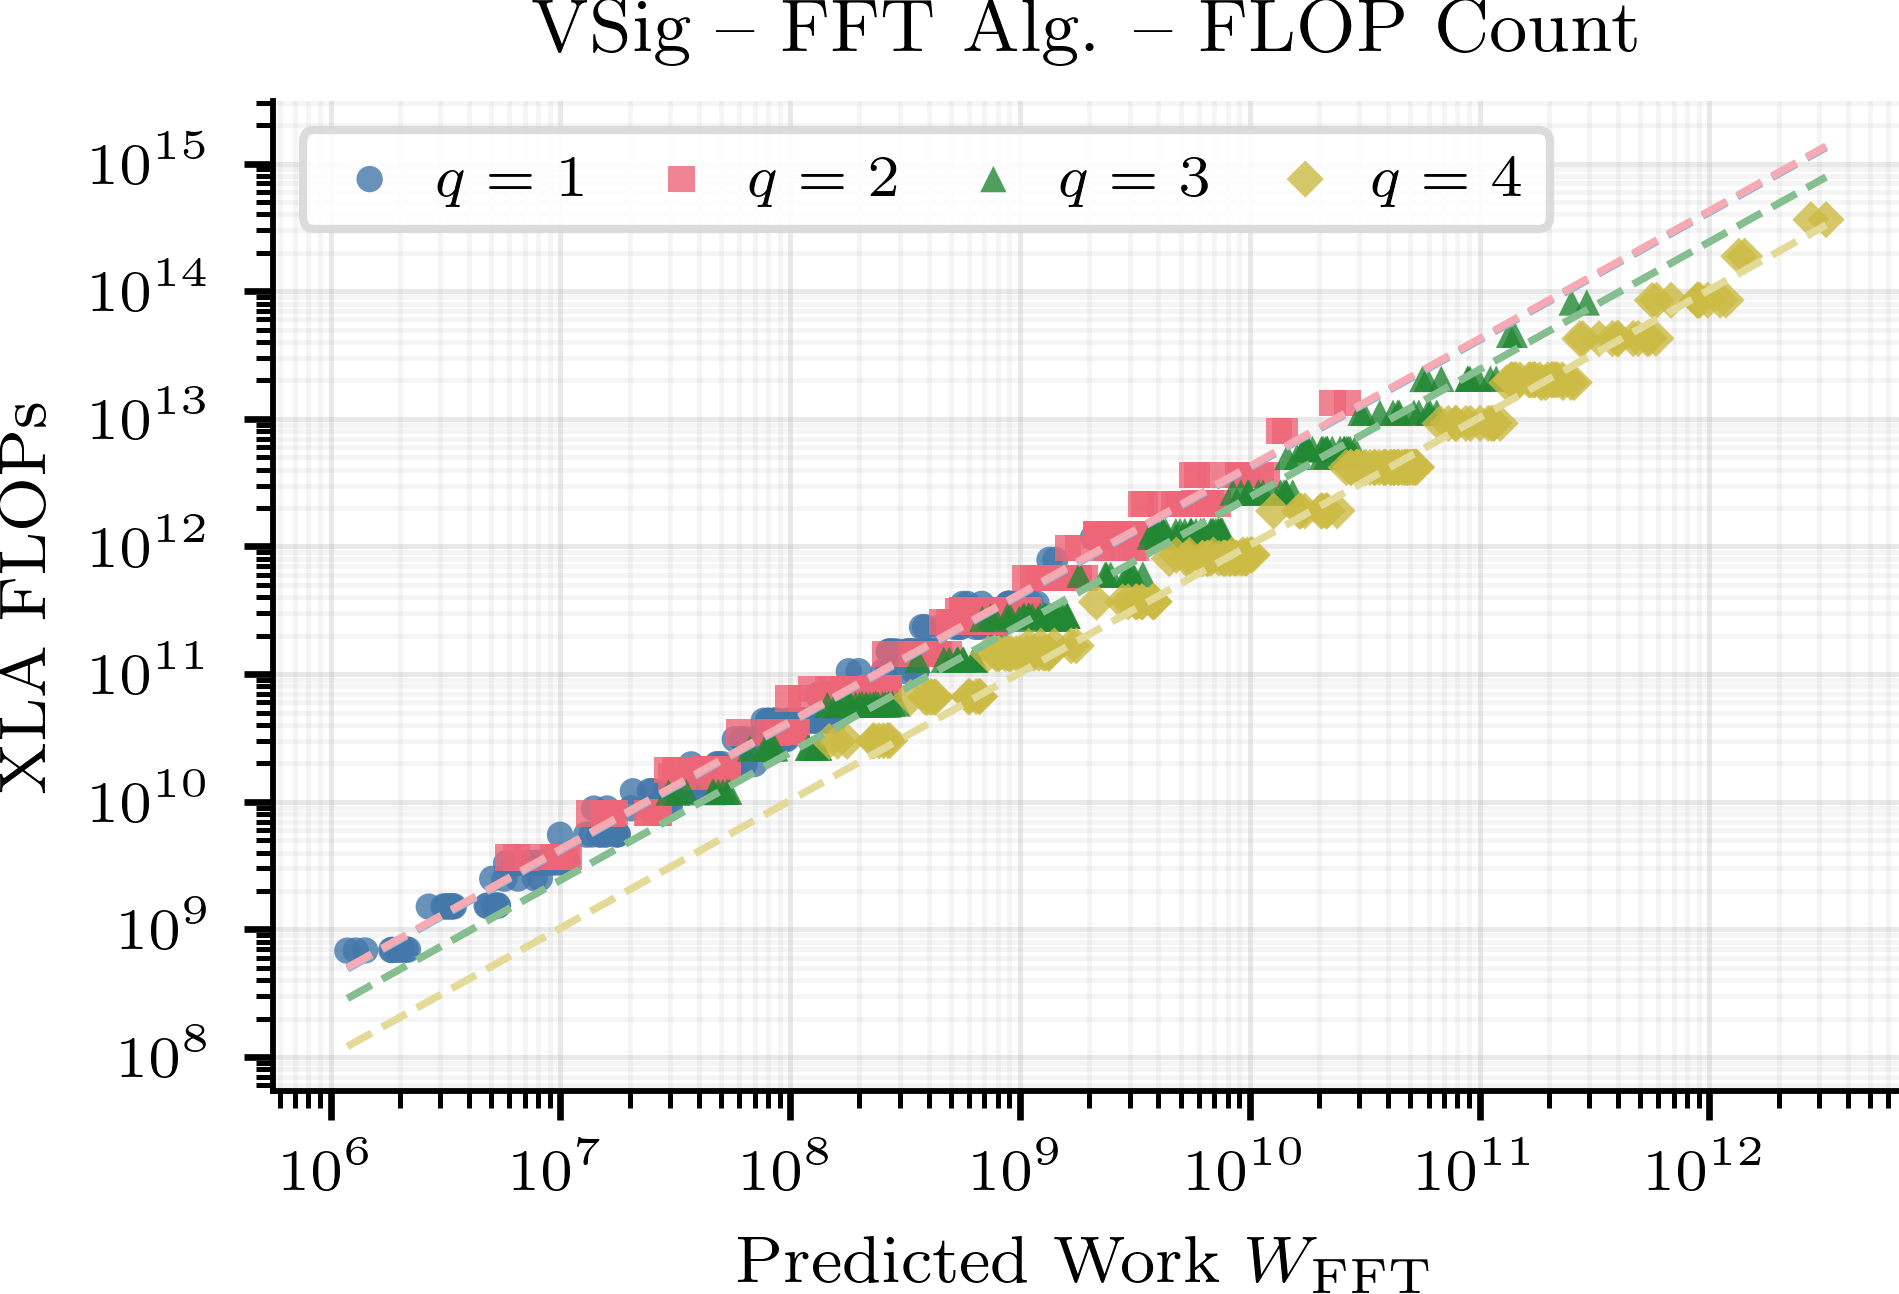

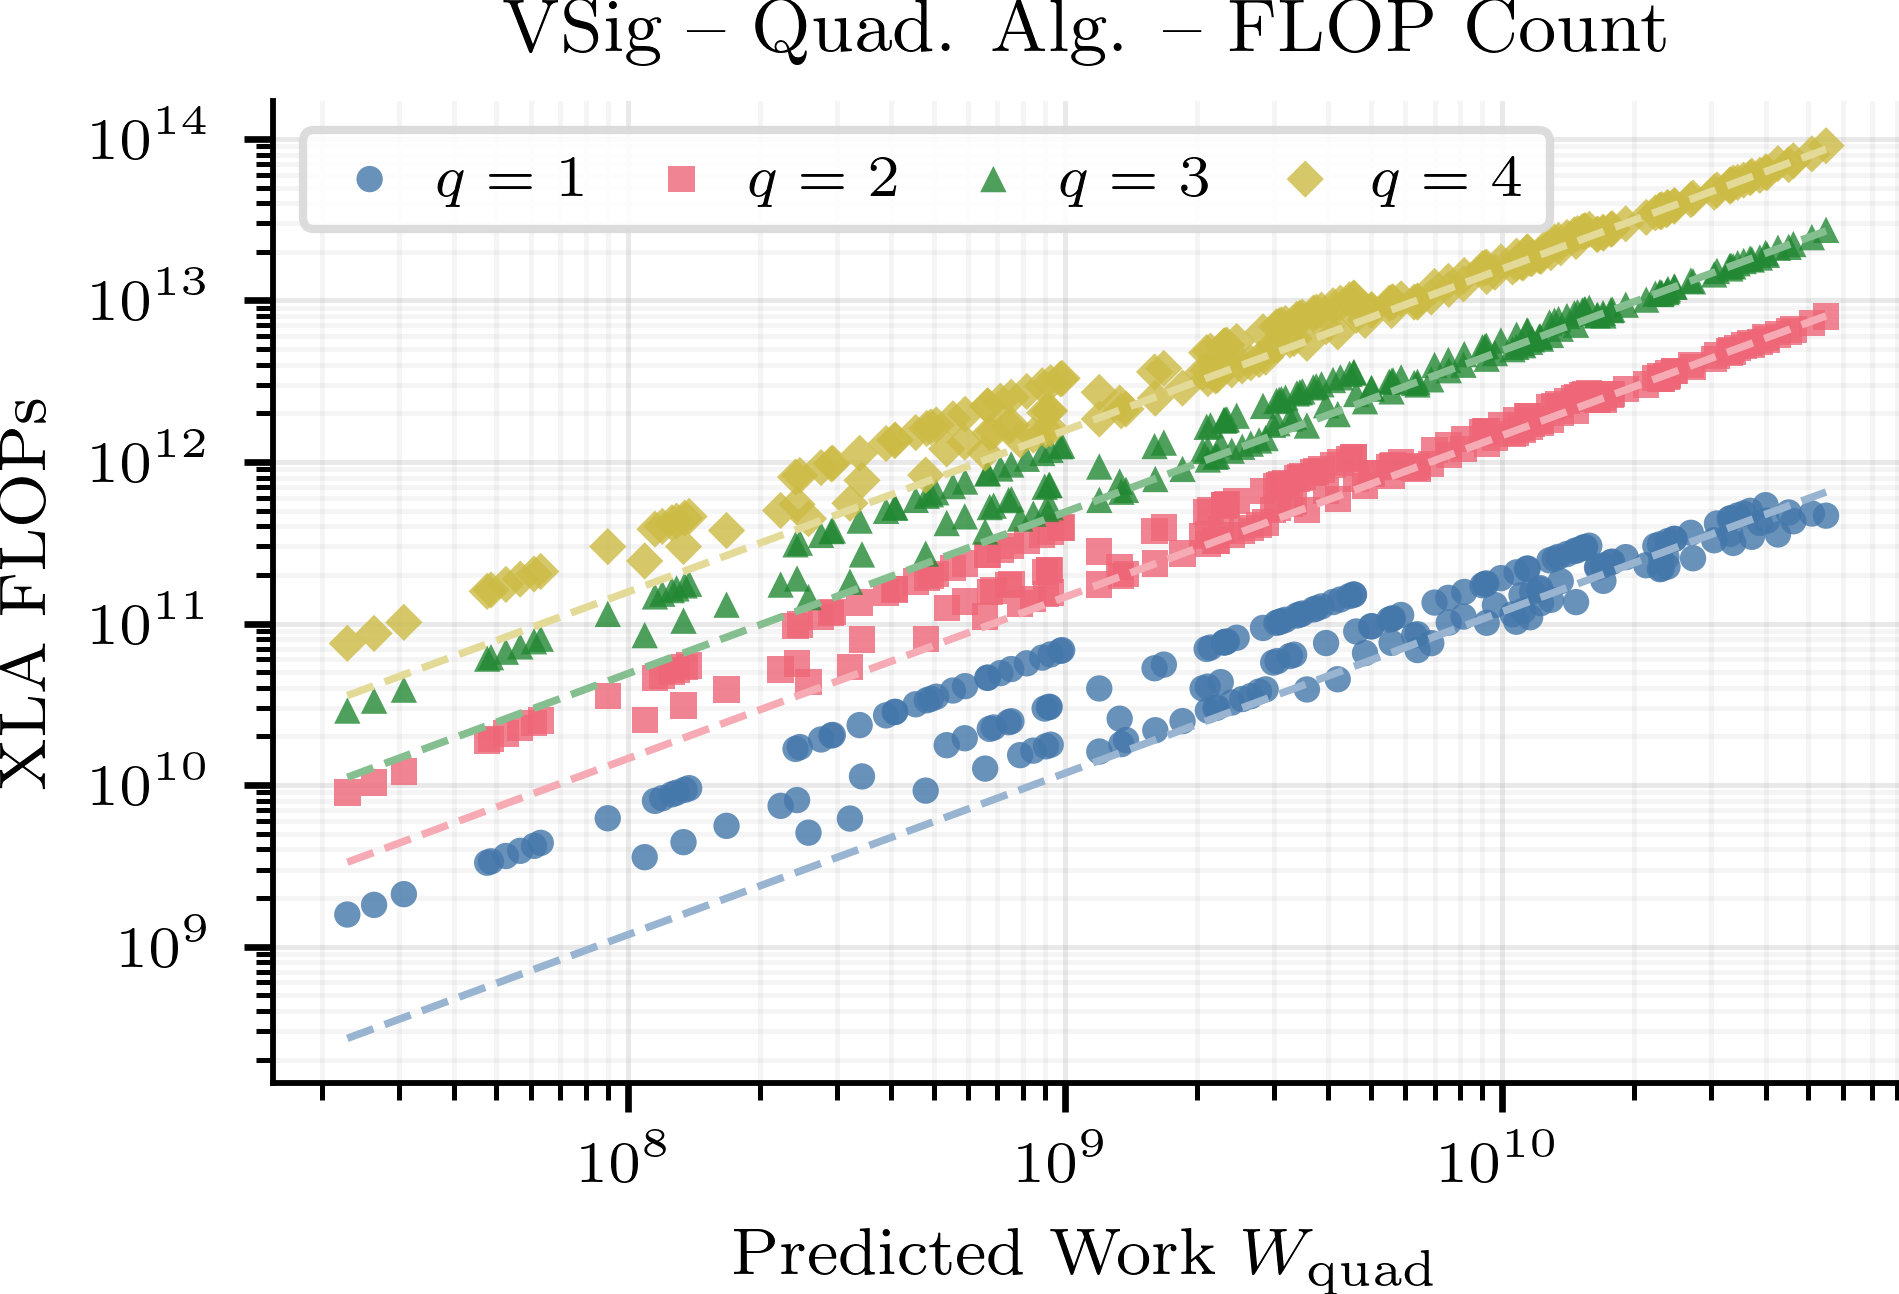

In [70]:
from pathlib import Path
from IPython.display import display, Image
import pandas as pd

out = Path(OUTPUT_DIR)
tag = FLOP_REGIME.lower()

summary_csv = out / f"vsig_flop_scaling_{tag}_summary.csv"
if summary_csv.exists():
    pass
    #display(pd.read_csv(summary_csv))

for stem in [f"vsig_flop_scaling_{tag}_fft_byq",
             f"vsig_flop_scaling_{tag}_quad_byq"]:
    p = out / f"{stem}.png"
    if p.exists():
        display(Image(str(p)))


/var/folders/_7/yfm9jdbx55x4s11pwkfrl5f40000gn/T/ipykernel_53122/741480529.py:45: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


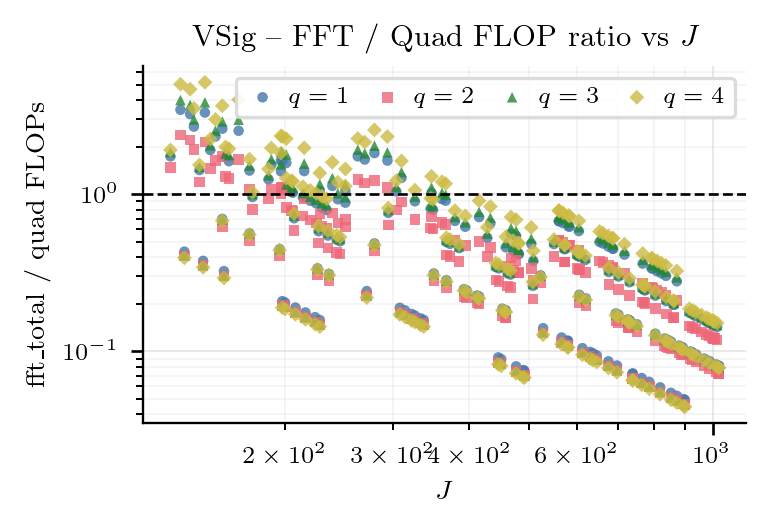

/var/folders/_7/yfm9jdbx55x4s11pwkfrl5f40000gn/T/ipykernel_53122/741480529.py:64: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


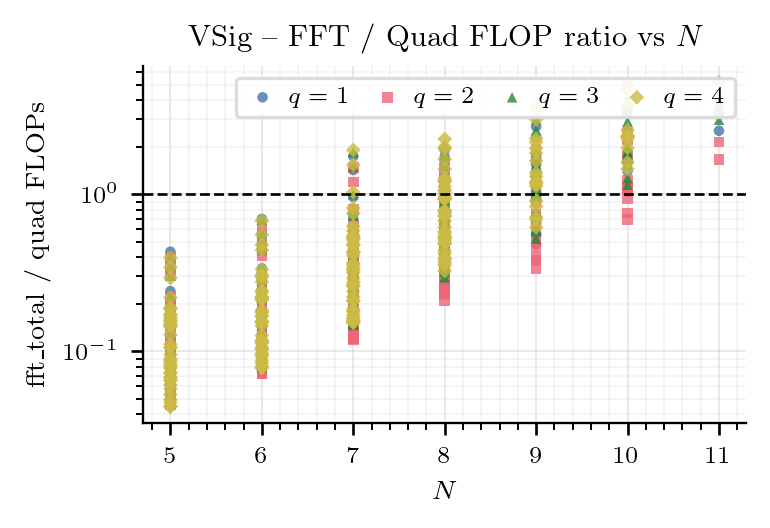

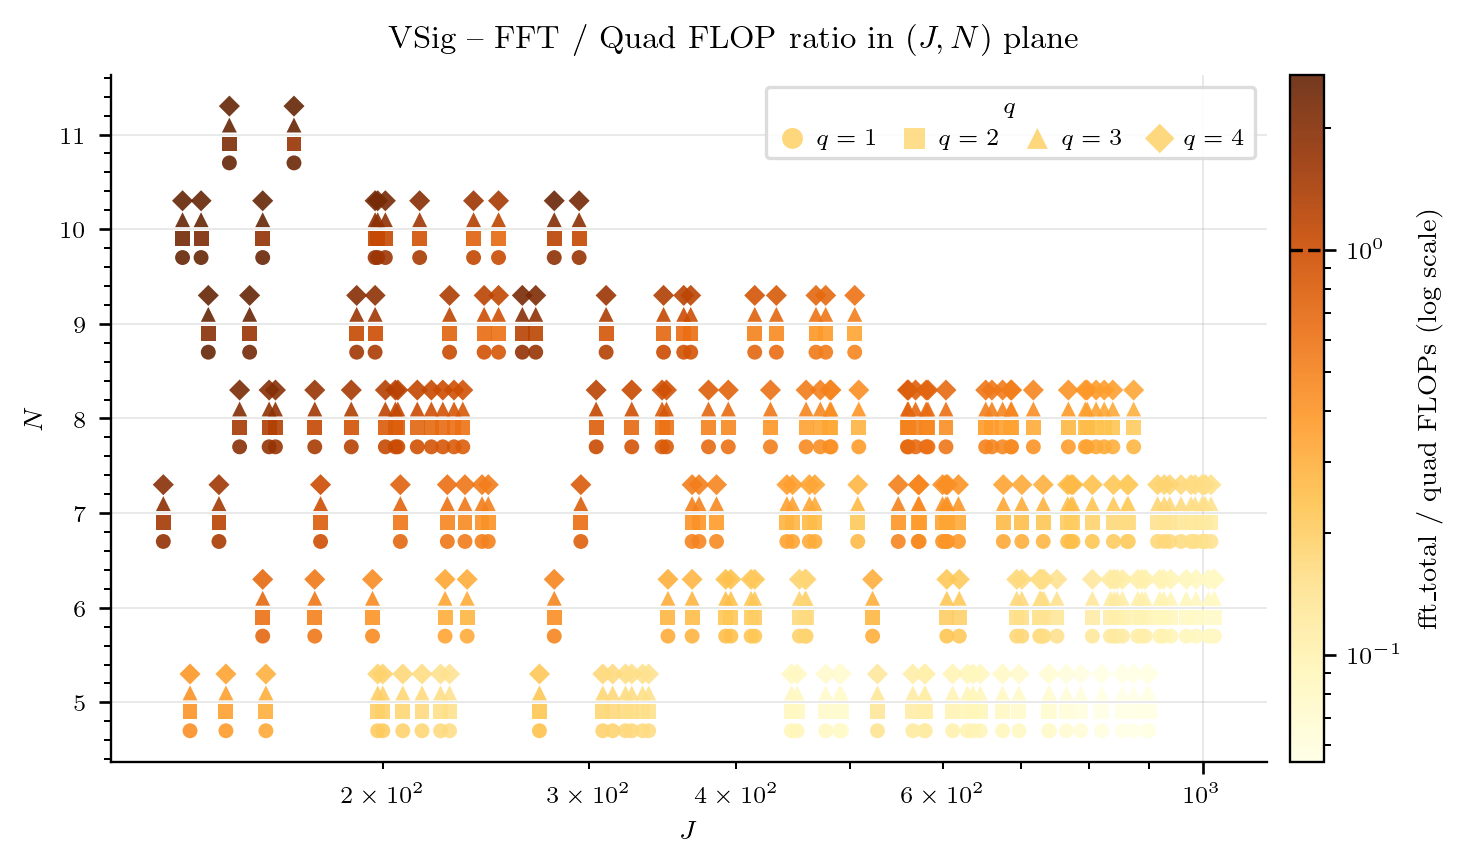

In [72]:
# ── Section 4b/c: FFT / quad FLOP ratio ─────────────────────────────────────
import sys
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

sys.path.insert(0, str(Path("validation").resolve().parents[1]))  # notebooks/
import _validation_util.plot_config as _pc  # noqa: F401
from _validation_util.plot_config import COLORS, MARKERS, SCATTER_SIZE, new_fig, savefig_fig

pkl = Path(OUTPUT_DIR) / f"vsig_flop_scaling_{FLOP_REGIME.lower()}.pkl"
df  = pd.read_pickle(pkl)
for c in ["fft_pre_flops", "fft_hot_flops", "quad_flops", "J", "N", "q"]:
    df[c] = pd.to_numeric(df[c], errors="coerce")
df = df.dropna(subset=["fft_pre_flops", "fft_hot_flops", "quad_flops"]).copy()
df["fft_total_flops"] = df["fft_pre_flops"] + df["fft_hot_flops"]
df["ratio"] = df["fft_total_flops"] / df["quad_flops"]
df["q"] = df["q"].astype(int)
df["N"] = df["N"].astype(int)
df["J"] = df["J"].astype(int)

qs        = sorted(df["q"].unique())
q_colors  = {q: COLORS[i % len(COLORS)]  for i, q in enumerate(qs)}
q_markers = {q: MARKERS[i % len(MARKERS)] for i, q in enumerate(qs)}

# ── Ratio vs J ───────────────────────────────────────────────────────────────
fig, ax = new_fig("half")
for q in qs:
    g = df[df["q"] == q]
    ax.scatter(g["J"], g["ratio"],
               s=SCATTER_SIZE, alpha=0.80,
               color=q_colors[q], marker=q_markers[q],
               edgecolors="none", label=f"$q={q}$")
ax.axhline(1.0, color="black", linestyle="--", linewidth=0.8)
ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlabel("$J$")
ax.set_ylabel("fft_total / quad  FLOPs")
ax.set_title("VSig -- FFT / Quad FLOP ratio vs $J$")
ax.minorticks_on()
ax.grid(True, which="minor", alpha=0.12)
ax.legend(ncol=len(qs), loc="upper right")
plt.tight_layout()
plt.show()

# ── Ratio vs N ───────────────────────────────────────────────────────────────
fig, ax = new_fig("half")
for q in qs:
    g = df[df["q"] == q]
    ax.scatter(g["N"], g["ratio"],
               s=SCATTER_SIZE, alpha=0.80,
               color=q_colors[q], marker=q_markers[q],
               edgecolors="none", label=f"$q={q}$")
ax.axhline(1.0, color="black", linestyle="--", linewidth=0.8)
ax.set_yscale("log")
ax.set_xlabel("$N$")
ax.set_ylabel("fft_total / quad  FLOPs")
ax.set_title("VSig -- FFT / Quad FLOP ratio vs $N$")
ax.minorticks_on()
ax.grid(True, which="minor", alpha=0.12)
ax.legend(ncol=len(qs), loc="upper right")
plt.tight_layout()
plt.show()

# ── Ratio in (J, N) plane ────────────────────────────────────────────────────
nq      = len(qs)
offsets = np.linspace(-0.3, 0.3, nq)

fig, ax = plt.subplots(figsize=(6, 3.5), layout="constrained")

ratio_vals = df["ratio"].values.astype(float)
vmin = np.nanpercentile(ratio_vals, 2)
vmax = np.nanpercentile(ratio_vals, 98)
norm = mcolors.LogNorm(vmin=max(vmin, 1e-2), vmax=max(vmax, 1.0))
cmap = plt.cm.YlOrBr

for i, q in enumerate(qs):
    g = df[df["q"] == q]
    sc = ax.scatter(g["J"], g["N"] + offsets[i],
                    c=g["ratio"], cmap=cmap, norm=norm,
                    s=SCATTER_SIZE * 2, alpha=0.90,
                    marker=MARKERS[i % len(MARKERS)],
                    edgecolors="none", label=f"$q={q}$")

ax.set_xscale("log")
ax.set_xlabel("$J$")
ax.set_ylabel("$N$")
ax.set_yticks(sorted(df["N"].unique()))
ax.minorticks_on()
ax.legend(title="$q$", loc="upper right", ncol=nq, frameon=True,
          markerscale=1.4, handletextpad=0.3)

cb = fig.colorbar(sc, ax=ax, orientation="vertical", fraction=0.05, pad=0.02)
cb.set_label("fft_total / quad  FLOPs  (log scale)")
cb.ax.axhline(1.0, color="black", linewidth=1.0, linestyle="--")

fig.suptitle("VSig -- FFT / Quad FLOP ratio in $(J, N)$ plane")
plt.show()


## 3. FSSK rough approximation vs predictor-corrector reference

Sweeps the FSSK state dimension R for each β.  The predictor-corrector with high
dyadic refinement serves as the reference.  A vsig (order=2) baseline error is
also recorded.


In [15]:
# ── Parameters (edit here) ──────────────────────────────────────────────────
# NOTE: fractional_fssk only supports beta ∈ (0.5, 1)
betas_fssk      = [0.6, 0.52]
R_values        = [2, 3, 4, 6, 8, 10]
trunc_fssk      = 6
batch_fssk      = 4
steps_fssk      = 32
T_fssk          = 1.0
pc_dyadic_fssk  = 9
coef_quad_fssk  = 64
seed_fssk       = 42
dim_fssk        = 3

In [16]:
import subprocess, sys
from pathlib import Path

script = Path("validation/sweep_fssk_approx.py").resolve()
result = subprocess.run(
    [sys.executable, str(script),
     "--betas",           *[str(b) for b in betas_fssk],
     "--R-values",        *[str(r) for r in R_values],
     "--trunc",           str(trunc_fssk),
     "--batch",           str(batch_fssk),
     "--steps",           str(steps_fssk),
     "--T",               str(T_fssk),
     "--pc-dyadic-order", str(pc_dyadic_fssk),
     "--coef-quad-order", str(coef_quad_fssk),
     "--seed",            str(seed_fssk),
     "--dim",             str(dim_fssk),
     "--output-dir",      str(Path("validation") / OUTPUT_DIR),
    ],
    cwd=str(script.parent.parent),
)
if result.returncode != 0:
    raise RuntimeError(f"sweep_fssk_approx.py failed (exit {result.returncode})")


Generating paths ...
  X.shape: (4, 33, 3)

════════════════════════════════════════════════════════════
  β = 0.6
════════════════════════════════════════════════════════════
  Computing PC reference (dyadic_order=9) ... done.
  R=  2 ... max err (lvl>0) = 2.650e-01
  R=  3 ... max err (lvl>0) = 4.272e-02
  R=  4 ... max err (lvl>0) = 1.029e-02
  R=  6 ... max err (lvl>0) = 4.976e-04
  R=  8 ... max err (lvl>0) = 4.100e-05
  R= 10 ... max err (lvl>0) = 6.310e-06

════════════════════════════════════════════════════════════
  β = 0.52
════════════════════════════════════════════════════════════
  Computing PC reference (dyadic_order=9) ... done.
  R=  2 ... max err (lvl>0) = 4.879e-01
  R=  3 ... max err (lvl>0) = 1.345e-01
  R=  4 ... max err (lvl>0) = 3.570e-02
  R=  6 ... max err (lvl>0) = 1.676e-03
  R=  8 ... max err (lvl>0) = 1.416e-04
  R= 10 ... max err (lvl>0) = 3.420e-05

Saved: validation/validation_outputs/fssk_approx.pkl
  fssk rows: 84
  vsig rows: 14


In [17]:
import subprocess, sys
from pathlib import Path

script = Path("validation/analyse_fssk_approx.py").resolve()
result = subprocess.run(
    [sys.executable, str(script),
     "--output-dir", str(Path("validation") / OUTPUT_DIR),
    ],
    cwd=str(script.parent.parent),
)
if result.returncode != 0:
    raise RuntimeError(f"analyse_fssk_approx.py failed (exit {result.returncode})")


Loaded: validation/validation_outputs/fssk_approx.pkl
  betas = [0.6, 0.52]
  R values = [2, 3, 4, 6, 8, 10]
  Saved: validation/validation_outputs/fssk_approx_b0p52.pdf
  Saved: validation/validation_outputs/fssk_approx_b0p52.png
  Saved: validation/validation_outputs/fssk_approx_b0p52_aggregate.pdf
  Saved: validation/validation_outputs/fssk_approx_b0p52_aggregate.png
  β=0.52: vsig baseline = 1.059e-05
  Saved: validation/validation_outputs/fssk_approx_b0p60.pdf
  Saved: validation/validation_outputs/fssk_approx_b0p60.png
  Saved: validation/validation_outputs/fssk_approx_b0p60_aggregate.pdf
  Saved: validation/validation_outputs/fssk_approx_b0p60_aggregate.png
  β=0.6: vsig baseline = 2.514e-06

Saved:
  validation/validation_outputs/fssk_approx_fssk.csv
  validation/validation_outputs/fssk_approx_vsig.csv

── FSSK aggregate error per beta × R (levels > 0) ───────────────
 beta  R  max_abs_entry
 0.52  2       0.487883
 0.52  3       0.134496
 0.52  4       0.035695
 0.52  6       

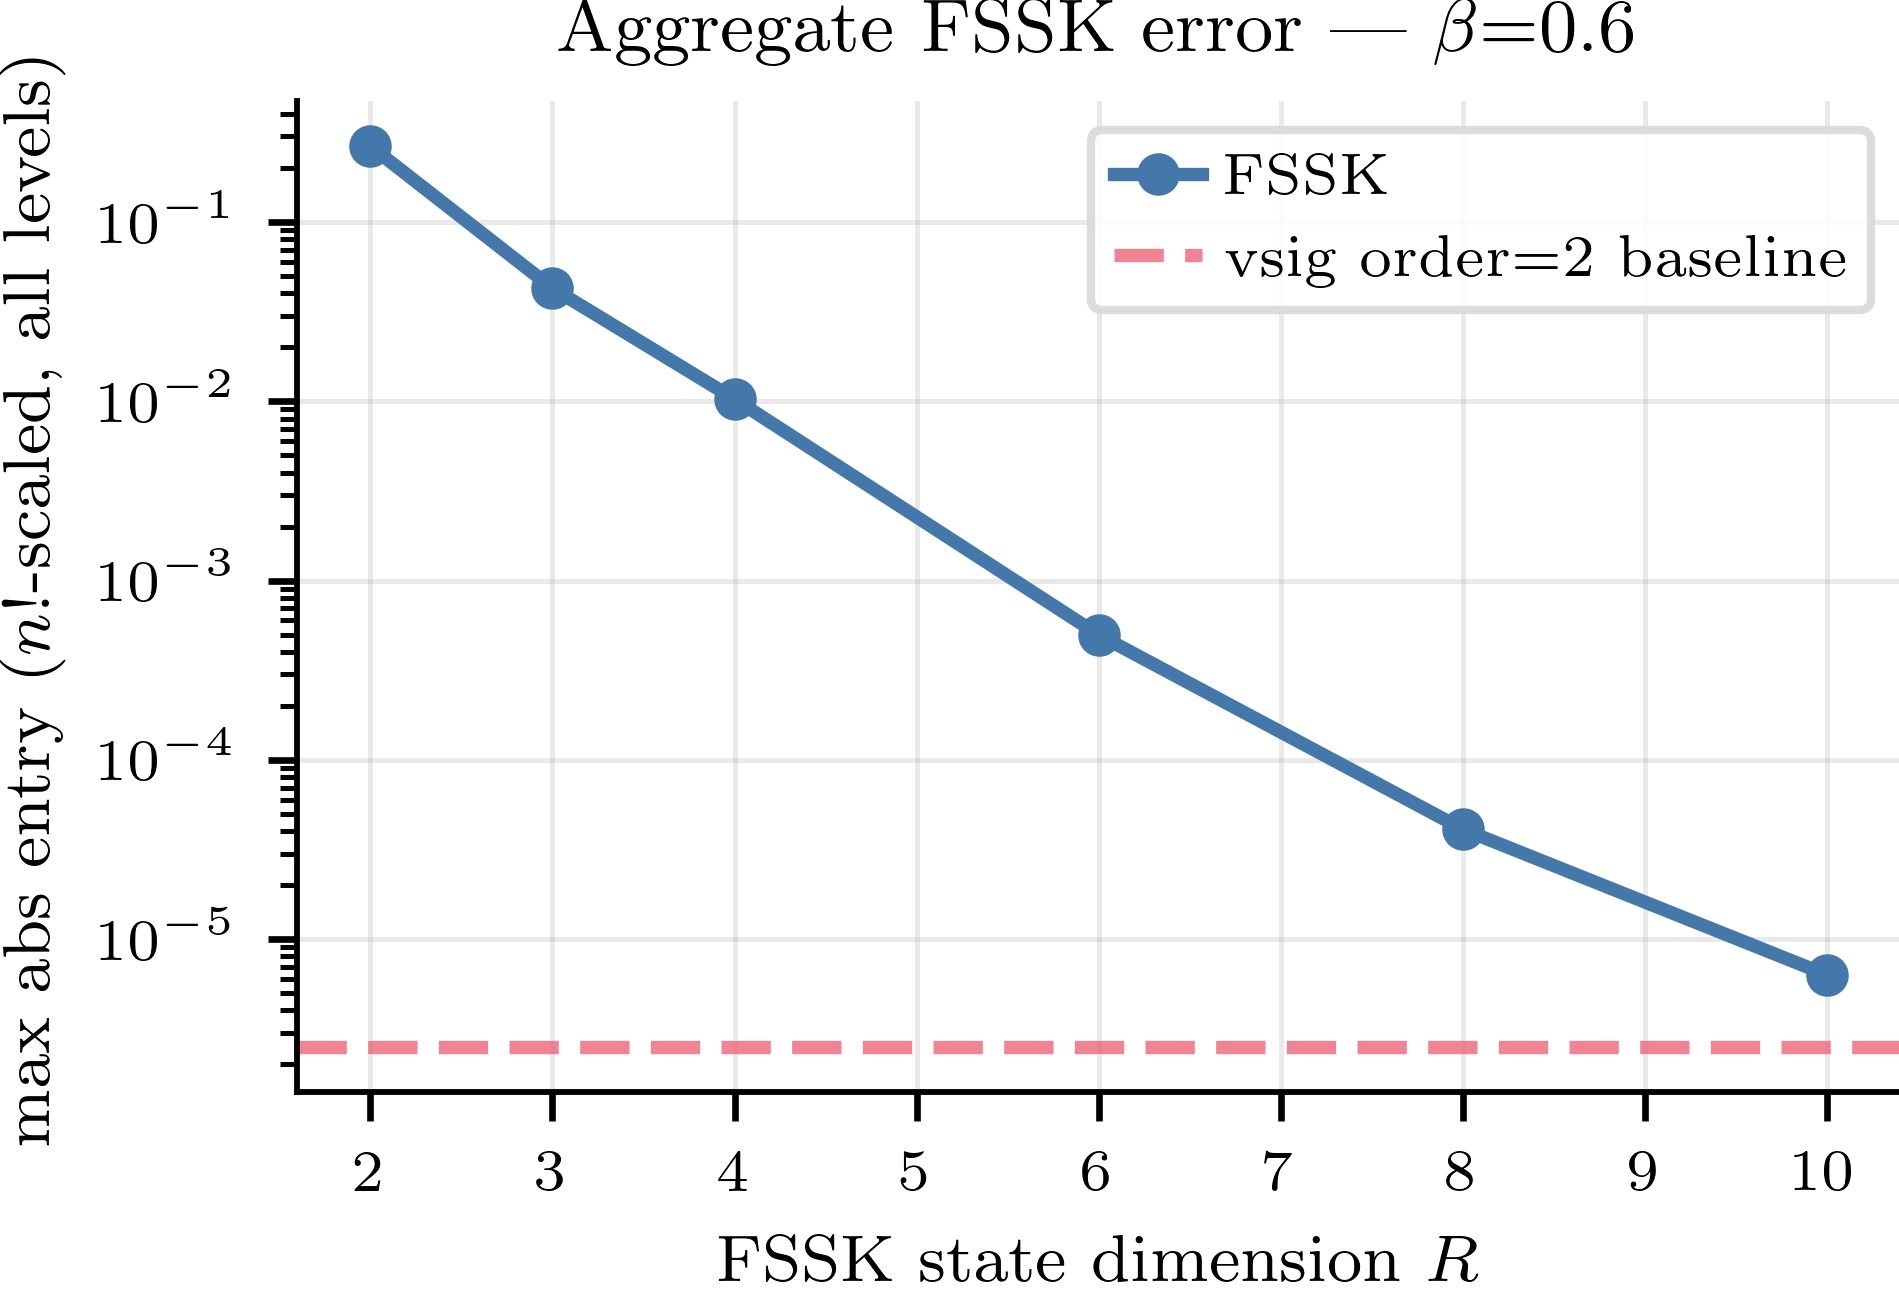

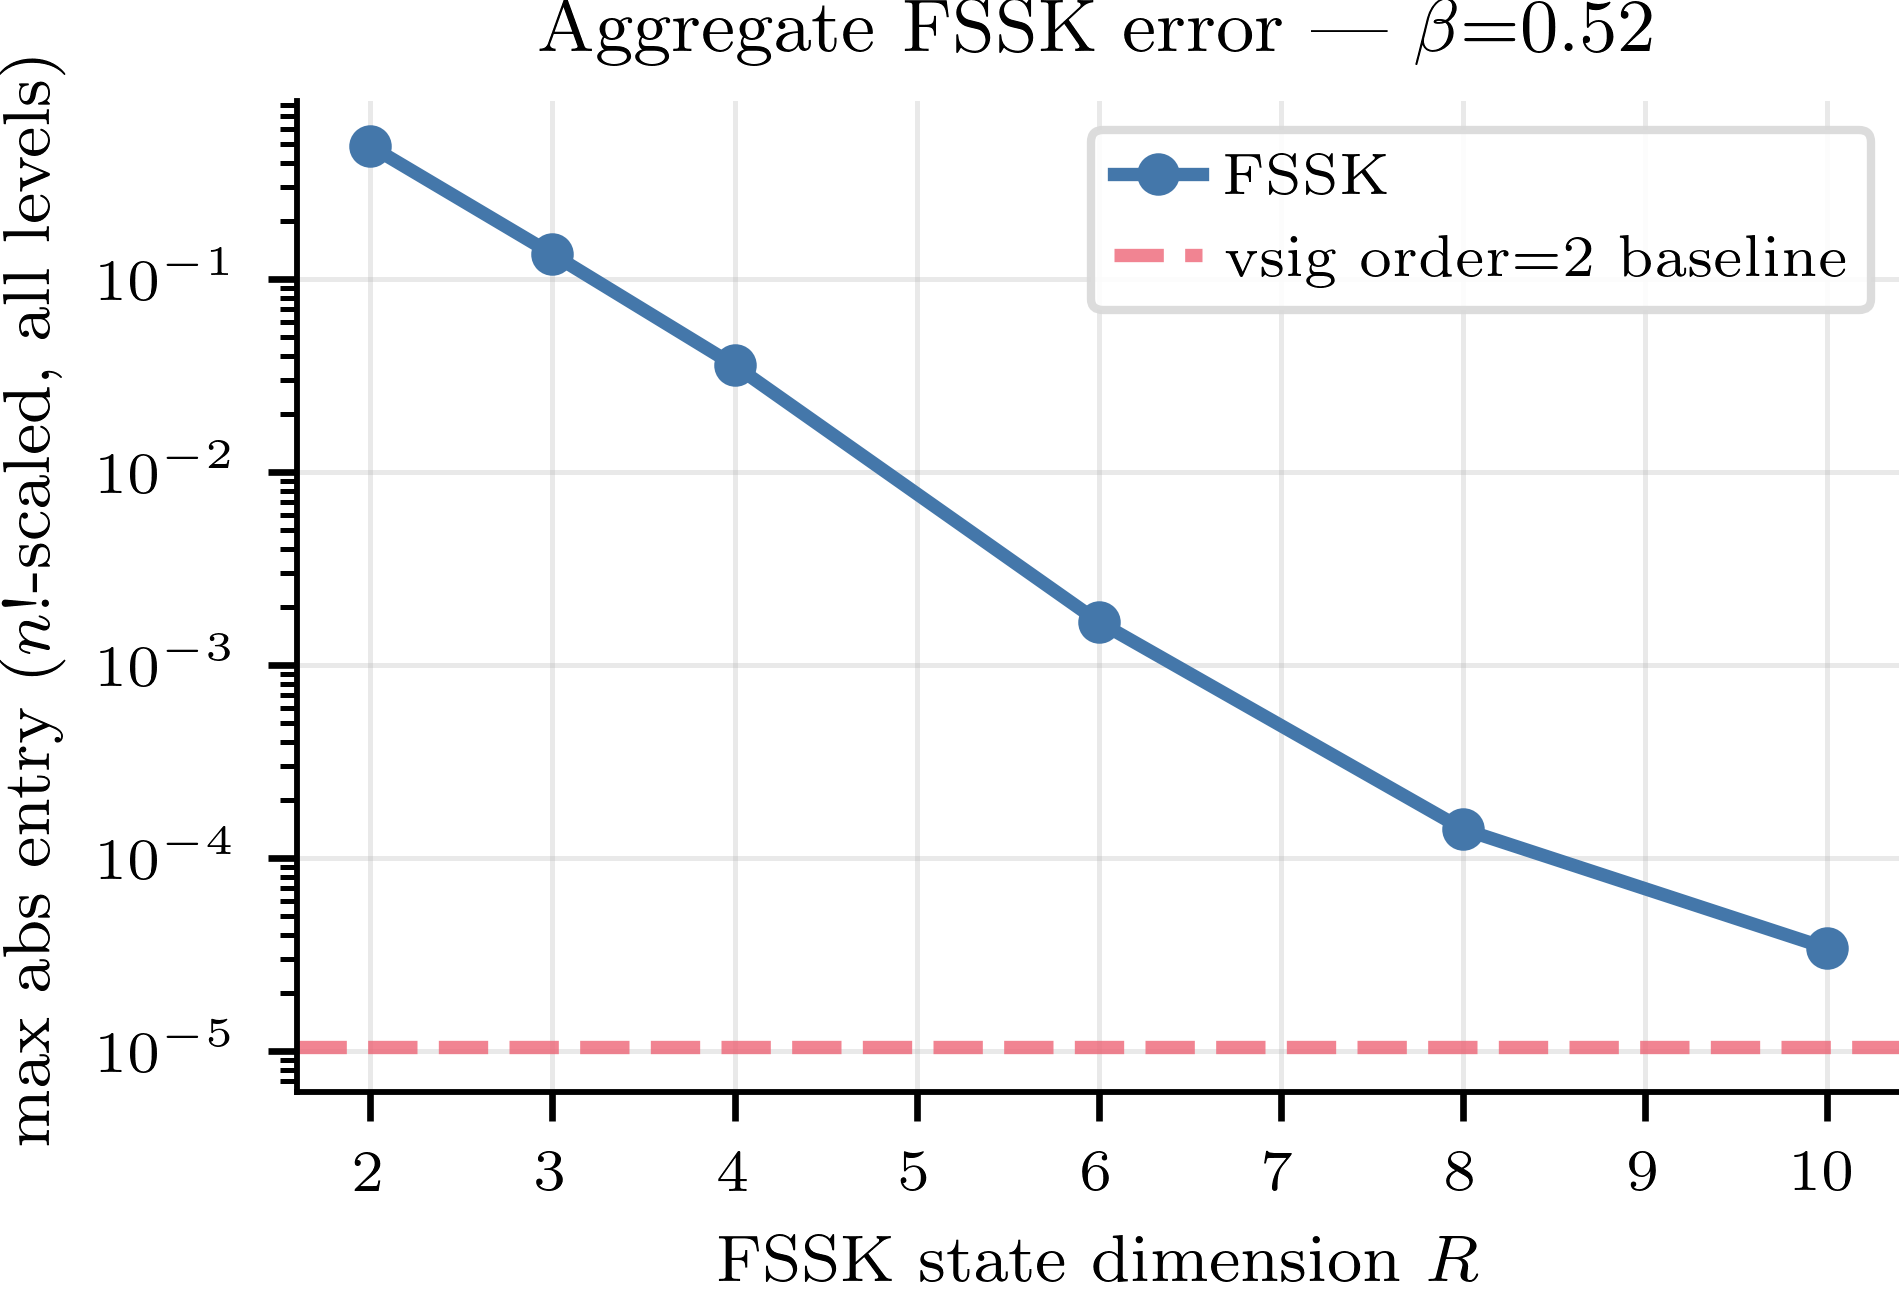

In [18]:
from pathlib import Path
from IPython.display import display, Image
import pandas as pd

out = Path("validation") / OUTPUT_DIR

if False: # display dfs
    display(pd.read_csv(out / "fssk_approx_vsig.csv").pivot(
        index="level", columns="beta", values="max_abs_entry"))
    display(pd.read_csv(out / "fssk_approx_fssk.csv")
            .query("level > 0")
            .groupby(["beta", "R"])["max_abs_entry"].max()
            .reset_index()
            .pivot(index="R", columns="beta", values="max_abs_entry"))

for beta in betas_fssk:
    beta_tag = f"b{beta:.2f}".replace(".", "p")
    for suffix in ["_aggregate"]: #["",]
        img = out / f"fssk_approx_{beta_tag}{suffix}.png"
        if img.exists():
            display(Image(filename=str(img)))


## 4. `FSSKConvolutionKernel` adapter correctness

Checks that `vsig_fft` through `ConvolutionKernel.fssk(...)` agrees with the
direct `StateSpaceSignature.vsig` to within tolerance on a fixed path/grid.


In [4]:
# ── Parameters (edit here) ──────────────────────────────────────────────────
adapter_steps         = 32
adapter_batch         = 4
adapter_trunc         = 6
adapter_T             = 1.0
adapter_orders        = [0, 1, 2]
adapter_schemes       = ["auto"]
adapter_dyadic_orders = [0,1,2]
adapter_seed          = 123

adapter_dim           = 3
adapter_q             = 2
adapter_R             = 2


In [5]:
import subprocess, sys
from pathlib import Path

script = Path("validation/validate_fssk_adapter.py").resolve()
result = subprocess.run(
    [sys.executable, str(script),
     "--steps",         str(adapter_steps),
     "--batch",         str(adapter_batch),
     "--trunc",         str(adapter_trunc),
     "--T",             str(adapter_T),
     "--orders",        *[str(o) for o in adapter_orders],
     "--schemes",        *[str(s) for s in adapter_schemes],
     "--dyadic-orders", *[str(d) for d in adapter_dyadic_orders],
     "--seed",          str(adapter_seed),
     "--dim",           str(adapter_dim),
     "--q",             str(adapter_q),
     "--R",             str(adapter_R),
     "--output-dir",    str(Path("validation") / OUTPUT_DIR),
    ],
    cwd=str(script.parent.parent),
)
if result.returncode != 0:
    raise RuntimeError(f"validate_fssk_adapter.py failed (exit {result.returncode})")


Generating paths ...
  X.shape: (4, 33, 3)
  kernel.q=2  kernel.m=3  R=2
Computing direct SSS reference ...
  SSS level shapes: [(4, 1), (4, 3), (4, 9), (4, 27), (4, 81), (4, 243), (4, 729)]
  vsig_fft order=0 scheme=auto dyadic=0 ... max diff (lvl>0) = 7.183e-04
  vsig_fft order=1 scheme=auto dyadic=0 ... max diff (lvl>0) = 1.117e-06
  vsig_fft order=2 scheme=auto dyadic=0 ... max diff (lvl>0) = 1.123e-11
  vsig_fft order=0 scheme=auto dyadic=1 ... max diff (lvl>0) = 3.707e-04
  vsig_fft order=1 scheme=auto dyadic=1 ... max diff (lvl>0) = 2.874e-07
  vsig_fft order=2 scheme=auto dyadic=1 ... max diff (lvl>0) = 7.176e-13
  vsig_fft order=0 scheme=auto dyadic=2 ... max diff (lvl>0) = 1.883e-04
  vsig_fft order=1 scheme=auto dyadic=2 ... max diff (lvl>0) = 7.286e-08
  vsig_fft order=2 scheme=auto dyadic=2 ... max diff (lvl>0) = 4.616e-14

Per-level max abs difference (n!-scaled, steps=32):
dyadic_order             0                                         1                               

/var/folders/_7/yfm9jdbx55x4s11pwkfrl5f40000gn/T/ipykernel_73133/3765251013.py:33: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


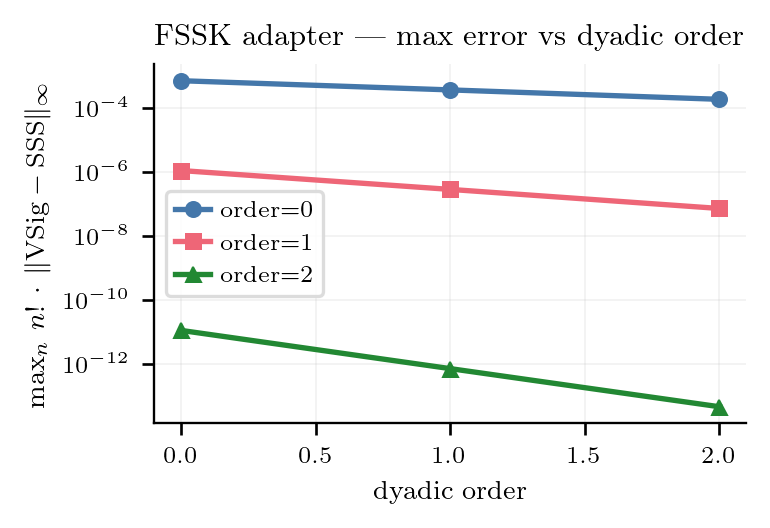

In [7]:
import sys
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt

sys.path.insert(0, str(Path("validation").resolve().parents[1]))
import _validation_util.plot_config as _pc  # noqa: F401
from _validation_util.plot_config import COLORS, MARKERS, new_fig

df = pd.read_csv(Path("validation") / OUTPUT_DIR / "fssk_adapter_errors.csv")
df = df[df["level"] > 0]

# max error over all levels, per (order, dyadic_order)
agg = (df.groupby(["order", "dyadic_order"])["max_abs_diff"]
         .max()
         .reset_index())

orders = sorted(agg["order"].unique())

fig, ax = new_fig("half")
for i, order in enumerate(orders):
    sub = agg[agg["order"] == order].sort_values("dyadic_order")
    ax.semilogy(sub["dyadic_order"], sub["max_abs_diff"],
                marker=MARKERS[i % len(MARKERS)],
                color=COLORS[i % len(COLORS)],
                label=f"order={order}")

ax.set_xlabel("dyadic order")
ax.set_ylabel(r"$\max_n\, n!\,\cdot\,\|\mathrm{VSig} - \mathrm{SSS}\|_\infty$")
ax.set_title("FSSK adapter — max error vs dyadic order")
ax.legend()
ax.grid(True, which="both", alpha=0.15)
plt.tight_layout()
plt.show()
